<a href="https://colab.research.google.com/github/wonderalexandre/MTLearn/blob/run-notebooks-colab/notebooks/experiments/Example_screws_filtering_add_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CFP custom scoring on the screws filtering dataset

This notebook runs one focused filtering example: learn the soft threshold `lambda_` of a single-attribute CFP scorer. The same simple scorer is also used in the segmentation notebook, so the two examples differ in the task loss and interpretation of the CFP output.

## Setup

Resolve the local checkout, import the libraries, fix the random seed, and choose the available device.

In [1]:
#!pip install mtlearn

from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Prefer the local build and local Python package when running inside the repo.
cwd = Path.cwd().resolve()
repo_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "pyproject.toml").exists()
        and (p / "mtlearn" / "python" / "mtlearn").exists()
    ),
    cwd,
)
for candidate in [
    repo_root / "build" / "mtlearn" / "bindings",
    repo_root / "mtlearn" / "python",
]:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

import mtlearn
from mtlearn import morphology
from mtlearn.layers import ConnectedFilterPreprocessingLayer
from mtlearn.layers.cfp import ScoringModel
import mtlearn.layers.cfp as cfp

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
generator = torch.Generator().manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("repo_root:", repo_root)
print("device:", device)

repo_root: /Volumes/SSD/GitHub/mtlearn
device: mps


## Experiment configuration

The target is a hard circularity filter on a min-tree. The learnable CFP scorer uses the same attribute and replaces the hard threshold with a sigmoid gate.

In [ ]:
DATASET_NAME = "screws_segmentation"
NUM_ROWS = 256
NUM_COLS = 256
BATCH_SIZE = 8
OUTPUT_SCALE = 255.0

TARGET_TREE_TYPE = "min-tree"
TARGET_TREE_ENUM = morphology.TreeType.MIN_TREE
TARGET_ATTRIBUTE = morphology.Attribute.CIRCULARITY
TARGET_ATTRIBUTE_TYPE = morphology.AttributeType.CIRCULARITY
TARGET_THRESHOLD_ORIGINAL = 0.6

FILTER_KEY = "min_circularity_soft_threshold"
INITIAL_LAMBDA = 0.0
SCORE_SHARPNESS = 20.0
CLAMP_LOGIT = 12.0
LEARNING_RATE = 0.01
NUM_EPOCHS = 100
REPORT_EPOCHS = {1, 5, 10, 20, 50, 100}

config = {
    "task": "filtering",
    "tree": TARGET_TREE_TYPE,
    "attribute": TARGET_ATTRIBUTE.name,
    "target_threshold_original": TARGET_THRESHOLD_ORIGINAL,
    "scoring": "single_attribute_soft_threshold",
    "initial_lambda": INITIAL_LAMBDA,
    "score_sharpness": SCORE_SHARPNESS,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
}
display(pd.DataFrame([config]))

## Dataset

The dataset provides normalized input images and normalized targets. The target image is generated on the original `uint8` image by applying a hard attribute filter with `CIRCULARITY > 0.6`.

screws_segmentation: already available at /Volumes/SSD/GitHub/mtlearn/dat/screws_segmentation
trainset: 35
testset: 15


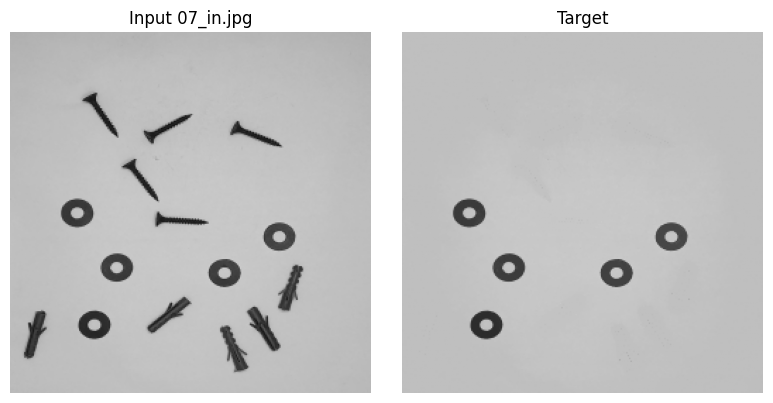

In [3]:
def make_attribute_filter_target(tree_type, attr_type, threshold):
    def target_fn(img):
        img_u8 = np.asarray(img)
        if img_u8.ndim != 2:
            raise ValueError(f"Expected grayscale image (H, W), got shape={img_u8.shape}")
        if img_u8.dtype != np.uint8:
            img_u8 = np.clip(img_u8, 0, 255).astype(np.uint8)

        tree = morphology.build_tree(img_u8, tree_type)
        attr_values = morphology.compute_single_attribute(tree, attr_type)
        filters = morphology.create_attribute_filter(tree)
        return filters.filteringSubtractiveRule(attr_values > threshold)

    return target_fn


dir_name = str(mtlearn.data.ensure_dataset(DATASET_NAME))
dataset = mtlearn.datasets.GeneratedTargetImageDataset(
    root_dir=dir_name,
    numRows=NUM_ROWS,
    numCols=NUM_COLS,
    suffix_in="_in",
    grayscale=True,
    scale_in=True,
    scale_out=True,
    target_fn=make_attribute_filter_target(TARGET_TREE_TYPE, TARGET_ATTRIBUTE, TARGET_THRESHOLD_ORIGINAL),
)

trainset, testset = dataset.train_test_split(test_size=0.3, random_state=SEED)
print("trainset:", len(trainset))
print("testset:", len(testset))

image_in, image_target, name = trainset[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_in.squeeze().detach().numpy(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Input {name}")
axes[1].imshow(image_target.squeeze().detach().numpy(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Target")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

trainset = [(x.to(device), y.to(device), name) for x, y, name in trainset]
testset = [(x.to(device), y.to(device), name) for x, y, name in testset]
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=False,
    generator=generator,
)

## Scoring model

This is the minimal custom scorer used by both notebooks. It learns one scalar parameter, `lambda_`, and applies `sigmoid(score_sharpness * (attribute - lambda_))` to normalized node attributes.

In [4]:
class SingleAttributeSoftThresholdScorer(ScoringModel):
    kind = "single_attribute_soft_threshold"

    def __init__(self, num_features: int, *, initial_lambda: float = 0.0):
        super().__init__()
        if int(num_features) != 1:
            raise ValueError("single_attribute_soft_threshold requires exactly one feature.")
        self.num_features = int(num_features)
        self.initial_lambda = float(initial_lambda)
        self.lambda_ = torch.nn.Parameter(torch.tensor(self.initial_lambda, dtype=torch.float32))

    def forward(self, features, tree_info=None, context=None, *, beta_f=None, clamp=None):
        if features.dim() != 2 or features.size(1) != self.num_features:
            raise ValueError(f"expected features with shape (num_nodes, {self.num_features}), got {tuple(features.shape)}")

        beta = 1.0 if beta_f is None else float(beta_f)
        lambda_value = self.lambda_.to(dtype=features.dtype, device=features.device)
        logits = beta * (features[:, 0] - lambda_value)
        if clamp is not None:
            logits = torch.clamp(logits, clamp[0], clamp[1])
        return torch.sigmoid(logits)

    def to_config(self):
        return {"kind": self.kind, "initial_lambda": self.initial_lambda}


def create_single_attribute_soft_threshold_scorer(*, num_features: int, initial_lambda: float = 0.0, **options):
    if options:
        names = ", ".join(sorted(options))
        raise ValueError(f"unsupported single_attribute_soft_threshold scoring options: {names}")
    return SingleAttributeSoftThresholdScorer(num_features, initial_lambda=initial_lambda)


if "single_attribute_soft_threshold" not in cfp.SCORING_MODEL_REGISTRY.registered_kinds():
    cfp.SCORING_MODEL_REGISTRY.register(
        "single_attribute_soft_threshold",
        create_single_attribute_soft_threshold_scorer,
    )

## CFP layer

The CFP layer builds min-trees, computes circularity attributes, normalizes them with dataset-level `minmax01` statistics, and reconstructs an image after applying the learnable soft-threshold scores.

In [ ]:
SCORING_CONFIG = {
    "kind": "single_attribute_soft_threshold",
    "initial_lambda": INITIAL_LAMBDA,
}

cfp_layer = ConnectedFilterPreprocessingLayer(
    in_channels=1,
    filter_specs=[
        {
            "name": FILTER_KEY,
            "tree_type": TARGET_TREE_ENUM,
            "attributes": TARGET_ATTRIBUTE_TYPE,
            "score_sharpness": SCORE_SHARPNESS,
            "scoring": SCORING_CONFIG,
        }
    ],
    scale_mode="minmax01",
    device=device,
    clamp=CLAMP_LOGIT,
)

# Caching computes tree payloads and the raw-attribute min/max statistics used below.
trainloader_cached = cfp_layer.build_dataloader_cached(trainloader)
print("scoring config:", cfp_layer.get_config()["filter_specs"][0]["scoring"])
print("parameter contract:", cfp_layer.get_parameter_contract())

## Evaluation utilities

The projection utility reports the learned `lambda_` on the original attribute scale. The notebook does not estimate or report a separate normalized-parameter value.

In [ ]:
def lambda_to_original_attribute_scale(layer, filter_key=FILTER_KEY, attr_type=TARGET_ATTRIBUTE_TYPE):
    if layer.scale_mode != "minmax01":
        raise NotImplementedError("This notebook projects lambda only for scale_mode='minmax01'.")

    scorer = layer._scoring_models[filter_key]
    spec = layer._spec_by_key[filter_key]
    stat_key = layer._stat_key(spec.tree_key, attr_type)
    stats = layer._ds_stats[stat_key]

    lambda_param = scorer.lambda_.detach()
    amin = stats["amin"].to(dtype=lambda_param.dtype, device=lambda_param.device)
    amax = stats["amax"].to(dtype=lambda_param.dtype, device=lambda_param.device)
    denom = torch.clamp(amax - amin, min=layer.eps)
    lambda_original = amin + lambda_param * denom
    return {
        "filter_key": filter_key,
        "attribute": getattr(attr_type, "name", str(attr_type)),
        "scale_mode": layer.scale_mode,
        "score_sharpness": float(layer._spec_by_key[filter_key].score_sharpness),
        "lambda_original_projection": float(lambda_original.detach().cpu()),
        "attribute_min": float(amin.detach().cpu()),
        "attribute_max": float(amax.detach().cpu()),
    }


def evaluate_filter_state(layer, dataloader):
    was_training = layer.training
    layer.eval()
    totals = {
        "mse_cfp_vs_input": 0.0,
        "mse_cfp_vs_target": 0.0,
        "mse_input_vs_target": 0.0,
        "mae_cfp_vs_input": 0.0,
    }
    max_abs_cfp_vs_input = 0.0
    count = 0

    with torch.no_grad():
        for batch_inputs, targets in dataloader:
            inputs = batch_inputs[0] if isinstance(batch_inputs, (tuple, list)) else batch_inputs
            predictions = layer(batch_inputs) / OUTPUT_SCALE
            count += targets.numel()
            totals["mse_cfp_vs_input"] += torch.sum((predictions - inputs) ** 2).item()
            totals["mse_cfp_vs_target"] += torch.sum((predictions - targets) ** 2).item()
            totals["mse_input_vs_target"] += torch.sum((inputs - targets) ** 2).item()
            totals["mae_cfp_vs_input"] += torch.sum(torch.abs(predictions - inputs)).item()
            max_abs_cfp_vs_input = max(
                max_abs_cfp_vs_input,
                float(torch.max(torch.abs(predictions - inputs)).detach().cpu()),
            )

    layer.train(was_training)
    report = lambda_to_original_attribute_scale(layer)
    report.update({key: value / count for key, value in totals.items()})
    report["max_abs_cfp_vs_input"] = max_abs_cfp_vs_input
    return report

## Initial state

Before any optimizer update, `lambda_` is fixed by the explicit initial value. The table reports only the original-scale projection and task metrics.

In [7]:
initial_report = evaluate_filter_state(cfp_layer, trainloader_cached)
print("Before training: lambda_ starts from the configured initial value.")
display(pd.DataFrame([initial_report]))

Before training: lambda_ starts from the configured initial value.


,filter_key,attribute,scale_mode,beta_f,lambda_original_projection,attribute_min,attribute_max,mse_cfp_vs_input,mse_cfp_vs_target,mse_input_vs_target,mae_cfp_vs_input,max_abs_cfp_vs_input
0,min_circularity_soft_threshold,CIRCULARITY,minmax01,20.0,0.0,0.0,1.0,0.000815,0.005181,0.009831,0.006017,0.272275


## Training

The training loop uses fixed hyperparameters: the optimizer learning rate is constant and `score_sharpness` is constant. At each report epoch, the notebook shows the same held-out image: input, target, and CFP output.

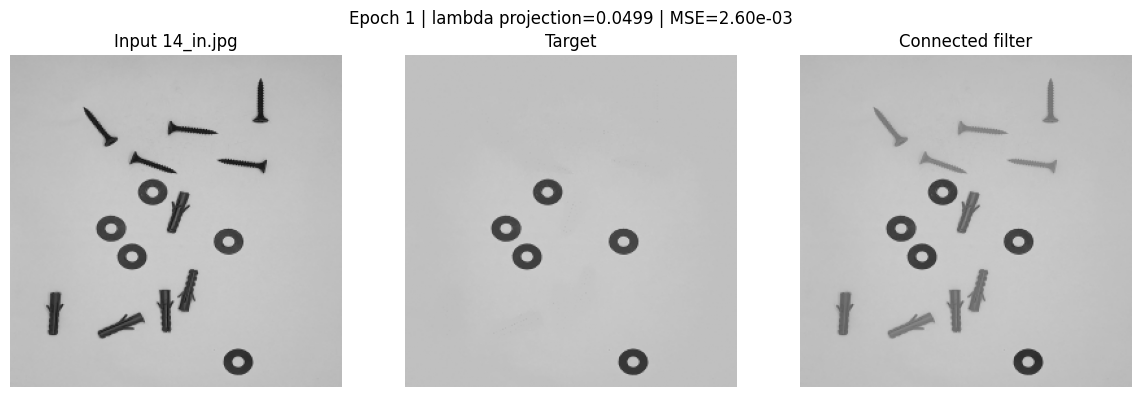

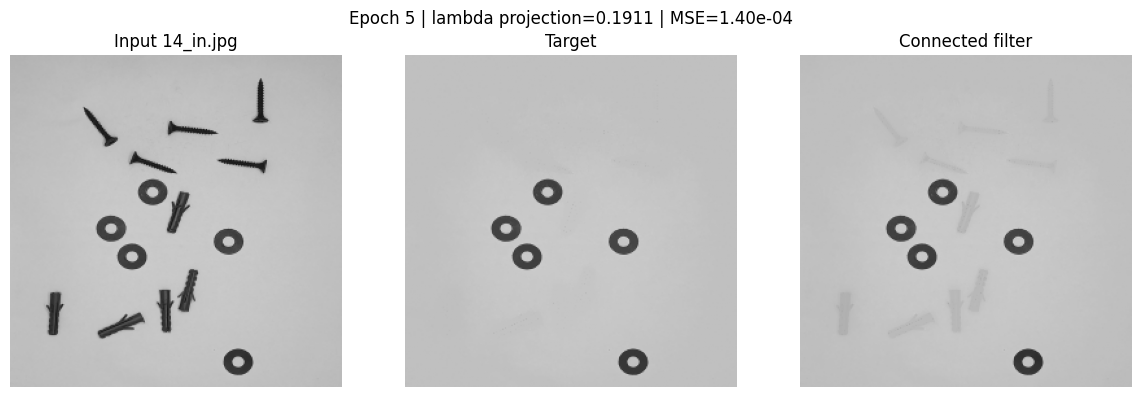

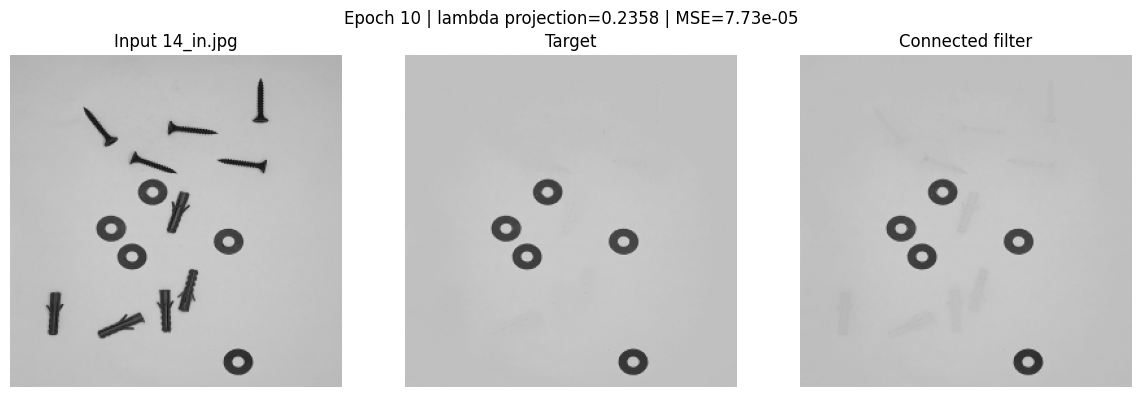

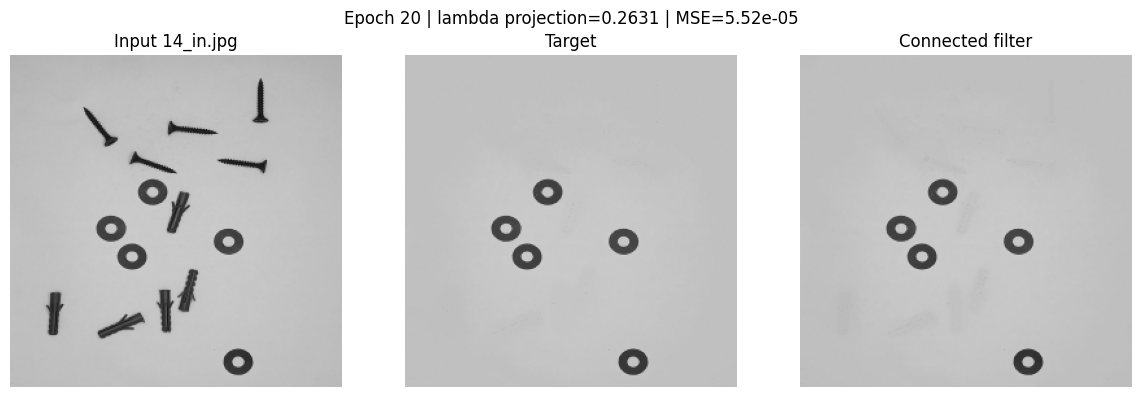

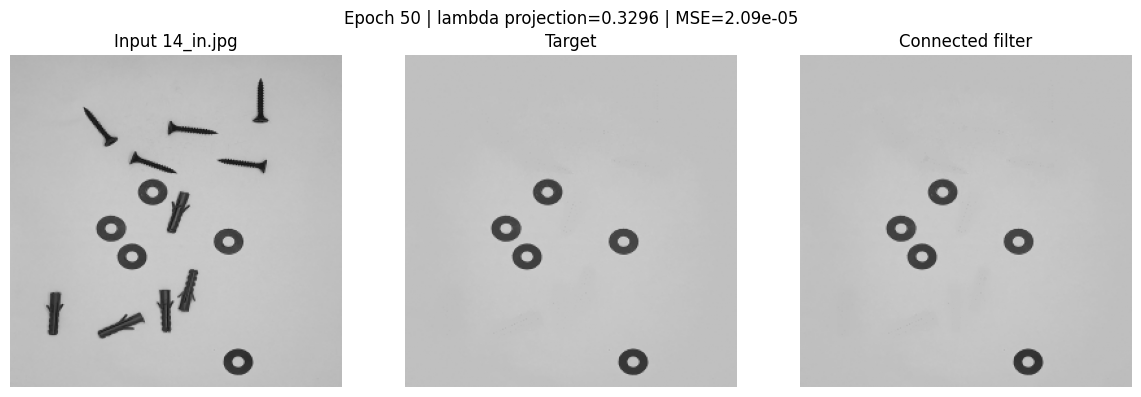

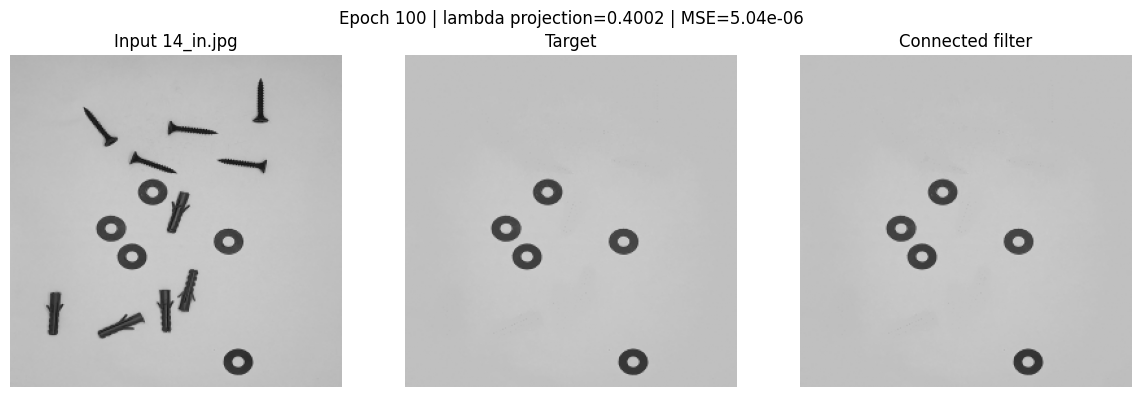

Training completed in 0.329 minutes.


In [8]:
loss_function = nn.MSELoss(reduction="mean")
optimizer = torch.optim.Adam(cfp_layer.parameters(), lr=LEARNING_RATE, weight_decay=0.0)
train_losses = []
report_rows = []
start = time.time()

viz_image, viz_target, viz_name = testset[0]

cfp_layer.train()
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss = 0.0
    last_grad_lambda = None

    for batch_inputs, targets in trainloader_cached:
        predictions = cfp_layer(batch_inputs) / OUTPUT_SCALE
        loss = loss_function(predictions, targets)

        optimizer.zero_grad()
        loss.backward()
        scorer = cfp_layer._scoring_models[FILTER_KEY]
        if scorer.lambda_.grad is not None:
            last_grad_lambda = float(scorer.lambda_.grad.detach().cpu())
        torch.nn.utils.clip_grad_norm_(cfp_layer.parameters(), max_norm=5.0)
        optimizer.step()

        epoch_loss += loss.item()

    train_epoch_loss = epoch_loss / len(trainloader_cached)
    train_losses.append(train_epoch_loss)

    if epoch in REPORT_EPOCHS:
        row = evaluate_filter_state(cfp_layer, trainloader_cached)
        row.update(
            {
                "epoch": epoch,
                "train_epoch_mse": train_epoch_loss,
                "learning_rate": LEARNING_RATE,
                "grad_lambda_last_batch": last_grad_lambda,
            }
        )
        report_rows.append(row)

        was_training = cfp_layer.training
        cfp_layer.eval()
        with torch.no_grad():
            viz_prediction = cfp_layer(viz_image.unsqueeze(0)) / OUTPUT_SCALE
        cfp_layer.train(was_training)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(viz_image[0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[0].set_title(f"Input {viz_name}")
        axes[1].imshow(viz_target[0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[1].set_title("Target")
        axes[2].imshow(viz_prediction[0, 0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[2].set_title("Connected filter")
        for axis in axes:
            axis.axis("off")
        fig.suptitle(
            f"Epoch {epoch} | lambda projection={row['lambda_original_projection']:.4f} | "
            f"MSE={row['mse_cfp_vs_target']:.2e}"
        )
        plt.tight_layout()
        plt.show()

elapsed_minutes = (time.time() - start) / 60.0
trajectory = pd.DataFrame(report_rows)
print(f"Training completed in {elapsed_minutes:.3f} minutes.")

## Results

The table shows the fixed-learning-rate trajectory. The plotted horizontal line is the hard threshold used to generate the target; the learned curve is the original-scale projection of `lambda_`.

,epoch,lambda_original_projection,mse_cfp_vs_target,mse_cfp_vs_input,train_epoch_mse,learning_rate
0,1,0.049934,0.002604,0.002516,0.004130,0.01
1,5,0.191099,0.000140,0.008369,0.000167,0.01
2,10,0.235809,0.000077,0.009024,0.000075,0.01
3,20,0.263123,0.000055,0.009251,0.000052,0.01
4,50,0.329646,0.000021,0.009552,0.000020,0.01
5,100,0.400239,0.000005,0.009709,0.000005,0.01


Final report
lambda_ is learned by the custom scorer; this report projects it to the original attribute scale.


,filter_key,attribute,scale_mode,beta_f,lambda_original_projection,attribute_min,attribute_max,mse_cfp_vs_input,mse_cfp_vs_target,mse_input_vs_target,mae_cfp_vs_input,max_abs_cfp_vs_input
0,min_circularity_soft_threshold,CIRCULARITY,minmax01,20.0,0.400239,0.0,1.0,0.009709,0.000005,0.009831,0.023893,0.709308


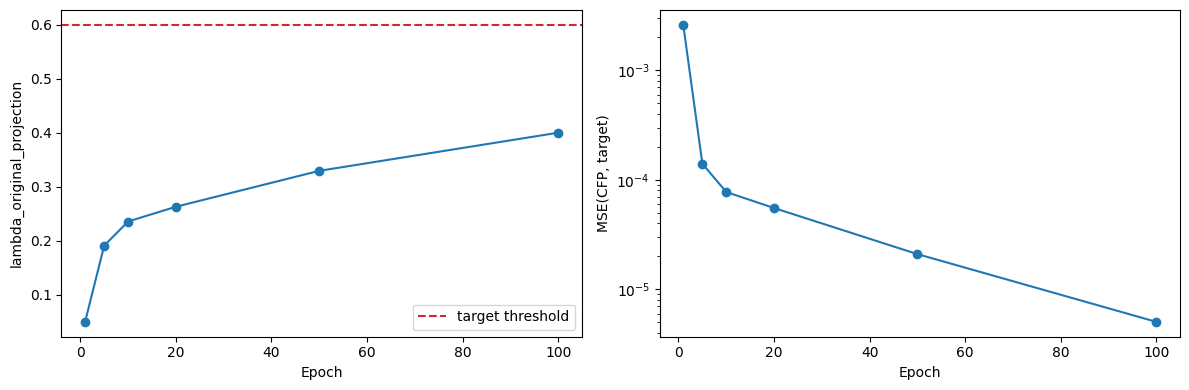

In [9]:
display_columns = [
    "epoch",
    "lambda_original_projection",
    "mse_cfp_vs_target",
    "mse_cfp_vs_input",
    "train_epoch_mse",
    "learning_rate",
]
display(trajectory[display_columns])

final_report = evaluate_filter_state(cfp_layer, trainloader_cached)
print("Final report")
print("lambda_ is learned by the custom scorer; this report projects it to the original attribute scale.")
display(pd.DataFrame([final_report]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(trajectory["epoch"], trajectory["lambda_original_projection"], marker="o")
axes[0].axhline(TARGET_THRESHOLD_ORIGINAL, color="tab:red", linestyle="--", label="target threshold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("lambda_original_projection")
axes[0].legend()

axes[1].semilogy(trajectory["epoch"], trajectory["mse_cfp_vs_target"], marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE(CFP, target)")
plt.tight_layout()
plt.show()